#TP1 : Perceptron
###Oumaima Belgaied _ RT4/2

#Génération et visualisation d’un dataset de classification

Dans cette partie, nous générons un dataset artificiel pour un problème de classification binaire en utilisant la fonction make_blobs de la bibliothèque scikit-learn. Le dataset contient 150 points, chacun décrit par deux caractéristiques (features). Les données sont réparties en deux clusters correspondant à deux classes.

Text(0.5, 1.0, 'Random Classification Data with 2 classes')

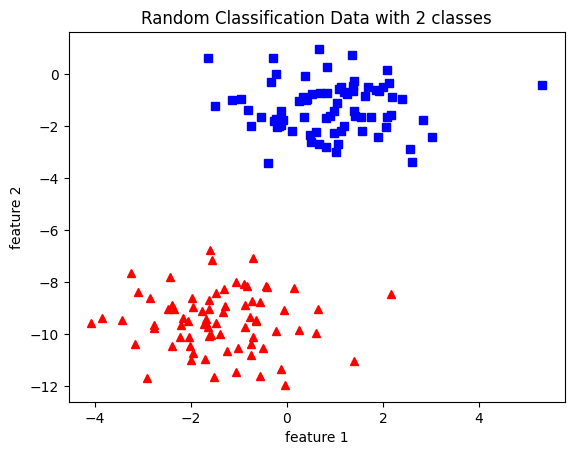

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets

X, y = datasets.make_blobs (n_samples=150, n_features=2,centers=2, cluster_std=1.05,random_state=2)

#Plotting
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title('Random Classification Data with 2 classes')

#fonction d'acrivation (heaviside)

In [ ]:
def acti_func(z):
    if z>0:
        return 1
    else:
        return 0

#Implémentation de l’algorithme du perceptron

Dans cette partie, on implémente l’algorithme du perceptron. L’algorithme apprend les poids du modèle à partir des données d’entraînement en parcourant plusieurs fois le dataset (epochs). Pour chaque exemple, il calcule une prédiction à l’aide d’une fonction d’activation ( heaviside ici ), puis met à jour les poids si la prédiction est incorrecte. Nous enregistrons également le nombre d’exemples mal classés à chaque itération afin d’observer la convergence de l’algorithme.

In [ ]:
def perceptron(X, y, lr, epochs):
  # X --> Inputs.
  # y --> labels/target.
  # lr --> learning rate.
  # epochs --> Number of iterations.
  # m-> number of training examples
  # n-> number of features
  m, n = X.shape
  # Initializing parameters (theta) to zeros.
  # +1 in n+1 for the bias term.
  w = np.zeros((n+1,1))
  # Empty list to store how many examples were
  # misclassified at every iteration.
  n_miss_list = []
  error_list=[]
  # Training.
  for epoch in range(epochs):
  # variable to store #misclassified.
    n_miss = 0
    # looping for every example.
    for idx, x_i in enumerate(X):
      # Insering 1 for bias, X0 = 1.
      x_i = np.insert(x_i, 0, 1).reshape(-1,1)
      # Calculating prediction/hypothesis.
      y_hat = acti_func(np.dot(x_i.T, w))
      # Updating if the example is misclassified.
      if (np.squeeze(y_hat) - y[idx]) != 0:
       w += lr * (y[idx] - y_hat) * x_i
       n_miss += 1
    # Appending number of misclassified examples
    # at every iteration.
    n_miss_list.append(n_miss)
    error_list.append(1-(m-n_miss)/m)
  return w, n_miss_list,error_list

#Visualisation de la frontière de décision

Après l’entraînement du perceptron, il est utile de visualiser la frontière de décision apprise par le modèle. Cette frontière correspond à la droite qui sépare les deux classes dans l’espace des caractéristiques.

In [ ]:
def plot_decision_boundary(X,y, w):
    # Assuming X has shape (m, 2) for two-dimensional features
    plt.figure(figsize=(10, 8))

    # Scatter plot for class 0 (assuming binary classification)
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', marker='^', label='Class 0')

    # Scatter plot for class 1
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', marker='s', label='Class 1')

    m = -w[1] / w[2]
    c = -w[0] / w[2]

    x1 = [min(X[:, 0]), max(X[:, 0])]
    x2 = m * x1 + c
    plt.plot(x1, x2, color='green' , label='Decision Boundary')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Perceptron Decision Boundary')
    plt.legend()
    plt.show()

In [ ]:
from random import shuffle
from sklearn.utils import shuffle


def generate_dataset(n_samples=10000, cluster_std1=0.25,center_box1=(1,0),cluster_std2=0.25,center_box2=(-1,0),random=False):
  if random:
    X1, y1 = datasets.make_blobs(n_samples=n_samples, n_features=2, centers=1, cluster_std=cluster_std1, random_state=2, center_box=center_box1)
    X2, y2 = datasets.make_blobs(n_samples=n_samples, n_features=2, centers=1, cluster_std=cluster_std2, random_state=2,center_box=center_box2)
  else:
    X1, y1 = datasets.make_blobs(n_samples=n_samples, n_features=2, centers=1, cluster_std=cluster_std1, center_box=center_box1)
    X2, y2 = datasets.make_blobs(n_samples=n_samples, n_features=2, centers=1, cluster_std=cluster_std2, center_box=center_box2)
  y2 = np.full((n_samples,), 1)

  X = np.concatenate((X1, X2), axis=0)
  y = np.concatenate((y1, y2), axis=0)

  # Shuffle the dataset
  X, y = shuffle(X, y, random_state=42)

  print("X shape:", X.shape)
  print("y shape:", y.shape)
  return X,y

experience 1 : σ1^2 = σ2^2 = 0.25

L’algorithme converge-t-il ? Pourquoi ?

Oui, l’algorithme du perceptron converge dans ce cas. Les deux classes sont générées à partir de distributions gaussiennes dont les moyennes sont différentes : μ₁ = (-1, 0) et μ₂ = (1, 0). De plus, la variance est faible (σ² = 0.25), ce qui signifie que les points sont peu dispersés autour de leurs centres respectifs. Par conséquent, les deux classes sont presque linéairement séparables dans l’espace des caractéristiques.

b. Limite de décision

La  limite de décision n’est pas unique. En effet, plusieurs droites peuvent séparer correctement les deux classes lorsque les données sont linéairement séparables. De plus, la modification de l’initialisation des poids ou de l’ordre des données peut conduire à une droite légèrement différente, bien que la séparation des classes reste correcte.

c. Accuracy sur l’ensemble de test

La justesse (accuracy) est calculée comme le rapport entre le nombre de prédictions correctes et le nombre total d’exemples dans l’ensemble de test

X shape: (250, 2)
y shape: (250,)


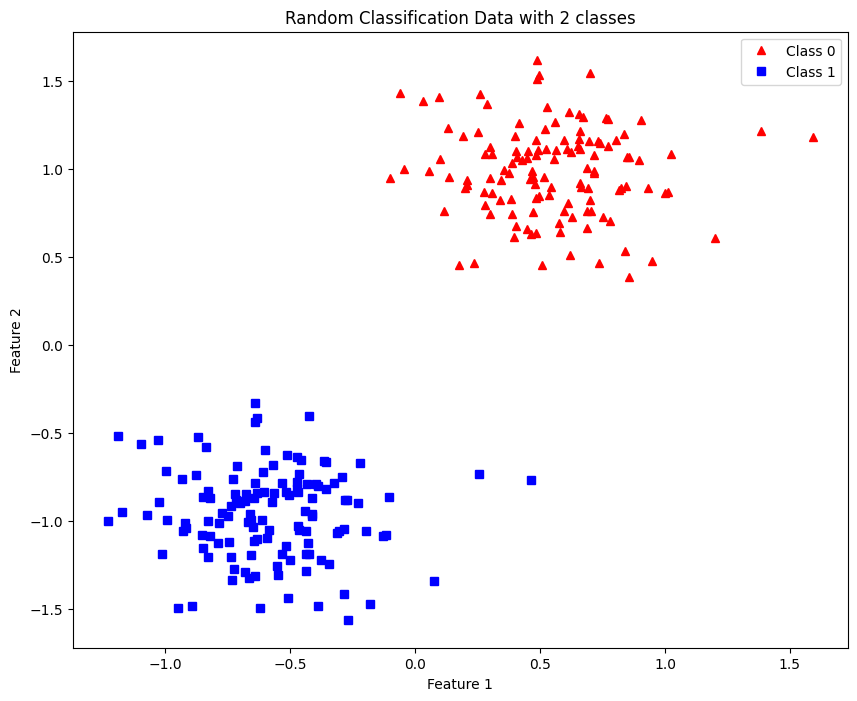

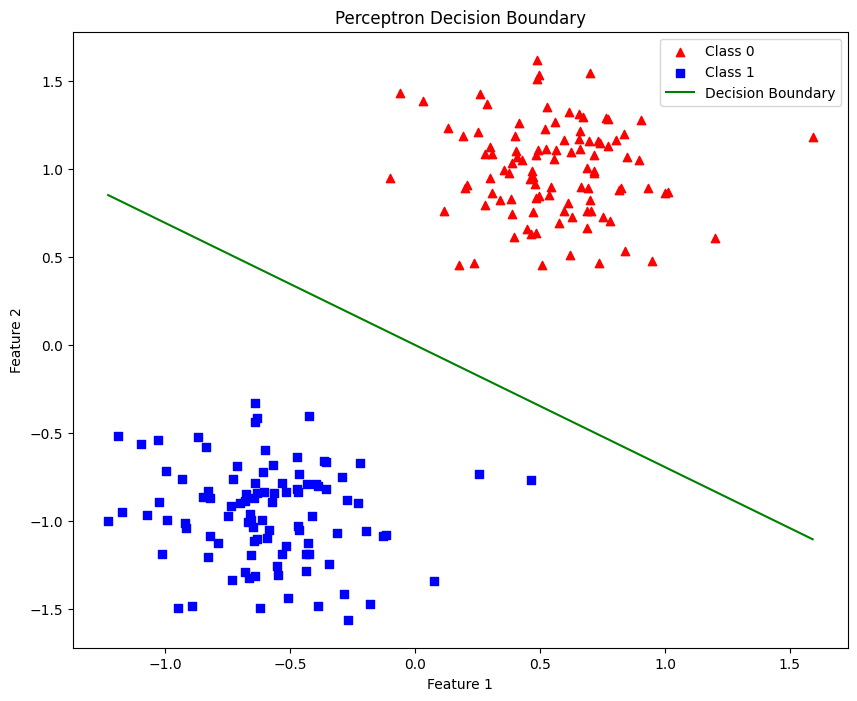

In [ ]:
from sklearn.model_selection import train_test_split

X,y=generate_dataset(n_samples=125,random=True)

# Plotting
fig = plt.figure(figsize=(10, 8))

# Plot points with label 0 in red triangles ('r^')
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^', label='Class 0')

# Plot points with label -1 in blue squares ('bs') - Corrected here
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs', label='Class 1')

# Set labels for the x and y axes
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Set the title of the plot
plt.title('Random Classification Data with 2 classes')

# Display a legend in the plot
plt.legend()

# Show the plot
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# training
w_train,_,_ = perceptron(X_train,y_train,0.01,3)

plot_decision_boundary(X_train,y_train, w_train)


La première fonction predict calcule les prédictions du modèle pour les données de test en utilisant les poids appris. La seconde fonction accuracy compare ces prédictions avec les vraies étiquettes afin de mesurer la justesse (accuracy) du modèle

In [ ]:
def predict(weights, X_test):
    Z = np.squeeze(np.dot(X_test,weights[1:3])+weights[0])
    predictions = np.where(Z >= 0, 1, 0)
    return predictions

def accuracy(weights, X_test, y_test):
    y_pred = predict(weights, X_test)
    accuracy = np.mean(y_pred == y_test)
    missed_predictions = X_test[y_pred != y_test]
    return accuracy , 1-accuracy

In [ ]:
print(accuracy(w_train,X_test,y_test))

(np.float64(1.0), np.float64(0.0))


#Experince 2 : sigma = 0.75

L’algorithme converge-t-il ? Pourquoi ?

Dans ce cas, la variance des distributions gaussiennes est plus grande (σ² = 0.75). Les points sont donc plus dispersés autour des centres, ce qui entraîne un chevauchement plus important entre les deux classes.Lorsque les données ne sont plus parfaitement linéairement séparables, l’algorithme du perceptron peut ne pas converger et continuer à effectuer des mises à jour des poids sans atteindre une solution stable.

X shape: (250, 2)
y shape: (250,)


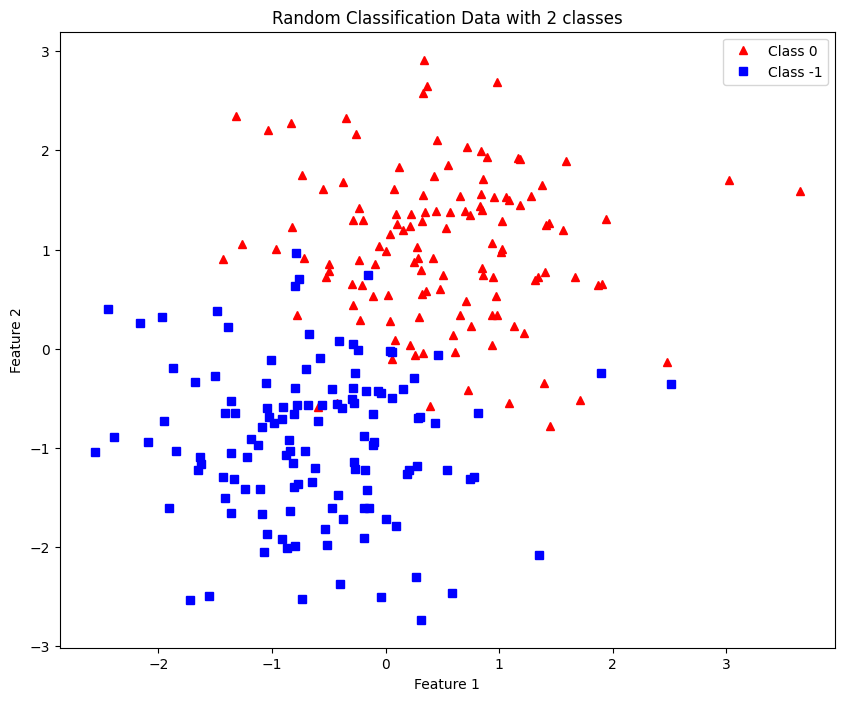

[[ 0.        ]
 [-0.00894779]
 [-0.01942688]]
(np.float64(0.98), np.float64(0.020000000000000018))


In [ ]:
X,y=generate_dataset(n_samples=125,cluster_std1=0.75,cluster_std2=0.75,random=True)

# Plotting
fig = plt.figure(figsize=(10, 8))

# Plot points with label 0 in red triangles ('r^')
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^', label='Class 0')

# Plot points with label -1 in blue squares ('bs') - Corrected here
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs', label='Class -1')

# Set labels for the x and y axes
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Set the title of the plot
plt.title('Random Classification Data with 2 classes')

# Display a legend in the plot
plt.legend()

# Show the plot
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

w_train,_ ,_= perceptron(X_train,y_train,0.01,3)

print(w_train)

print(accuracy(w_train,X_test,y_test))

#Experience

In [ ]:
def experience(n_samples,sigma):
  X,y=generate_dataset(n_samples=n_samples,cluster_std1=sigma,cluster_std2=sigma)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
  weights,_,_=perceptron(X_train,y_train,0.01,30)
  exp_accuracy,exp_error=accuracy(weights, X_test, y_test)
  return exp_accuracy,exp_error



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sigmas = [0.01, 0.1, 0.5, 0.7]

variances_error = []
means_error = []

for sigma in sigmas:
        print(f"*********for sigma = {sigma}********")
        errors=[]
        for i in range(30):
          print(f"experience {i+1} : ")
          exp_accuracy,exp_error=experience(125,sigma)
          print(f"accuracy : {exp_accuracy}**** error : {exp_error}")
          errors.append(exp_error)
        mean_error = np.mean(errors)
        variance_error = np.var(errors)
        means_error.append(mean_error)
        variances_error.append(variance_error)

plt.figure(figsize=(10, 6))

*********for sigma = 0.01********
experience 1 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 2 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 3 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 4 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 5 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 6 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 7 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 8 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 9 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 10 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 11 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** error : 0.0
experience 12 : 
X shape: (250, 2)
y shape: (250,)
accuracy : 1.0**** err

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

[np.float64(0.0), np.float64(0.0), np.float64(0.134), np.float64(0.23466666666666663)]


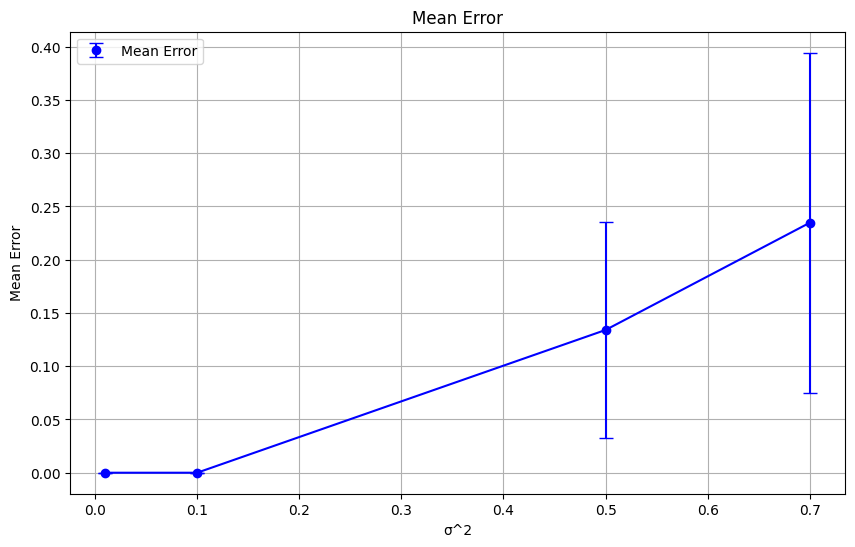

In [ ]:
print(means_error)

plt.figure(figsize=(10, 6))
plt.errorbar(sigmas, means_error, yerr=np.sqrt(variances_error), color='b', ecolor='blue', capsize=5,fmt='o', label='Mean Error')
plt.plot(sigmas, means_error, linestyle='-', marker='', color='blue')

plt.xlabel('σ^2')
plt.ylabel('Mean Error')
plt.title('Mean Error')
plt.legend()
plt.grid(True)
plt.show()

#